# Chapter 4：矩陣乘法與線性變換複合

> **3Blue1Brown — Essence of Linear Algebra**
>
> 矩陣乘法不是隨便定義的運算規則，它的本質是**線性變換的複合（composition）**。
> 當我們寫 $M_1 M_2$ 時，意思是「先做 $M_2$，再做 $M_1$」——把兩個變換串接成一個。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Helper: draw transformed grid + unit square ──────────────────────────

def draw_transformed(ax, matrix=None, title="", grid_range=4, n_lines=9):
    """
    Draw a transformed grid and unit square on the given axes.
    If matrix is None, draw the identity (original) grid.
    """
    M = np.eye(2) if matrix is None else np.array(matrix, dtype=float)
    ax.set_xlim(-grid_range, grid_range)
    ax.set_ylim(-grid_range, grid_range)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(0, color='grey', linewidth=0.3)
    ax.axvline(0, color='grey', linewidth=0.3)

    # Draw grid lines (transform each line)
    t = np.linspace(-grid_range, grid_range, 200)
    for k in np.linspace(-grid_range, grid_range, n_lines):
        # Vertical line x=k
        pts_v = M @ np.array([np.full_like(t, k), t])
        ax.plot(pts_v[0], pts_v[1], color='#cccccc', linewidth=0.5)
        # Horizontal line y=k
        pts_h = M @ np.array([t, np.full_like(t, k)])
        ax.plot(pts_h[0], pts_h[1], color='#cccccc', linewidth=0.5)

    # Draw unit square
    square = np.array([[0, 1, 1, 0, 0],
                       [0, 0, 1, 1, 0]])
    sq_t = M @ square
    ax.fill(sq_t[0], sq_t[1], alpha=0.25, color='#4CAF50')
    ax.plot(sq_t[0], sq_t[1], color='#4CAF50', linewidth=2)

    # Draw basis vectors
    origin = np.array([0, 0])
    i_hat = M @ np.array([1, 0])
    j_hat = M @ np.array([0, 1])
    ax.annotate('', xy=i_hat, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.annotate('', xy=j_hat, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.text(i_hat[0], i_hat[1] - 0.35, f'î={i_hat}', color='red', fontsize=8, ha='center')
    ax.text(j_hat[0] - 0.35, j_hat[1], f'ĵ={j_hat}', color='blue', fontsize=8, ha='center')

def draw_vector(ax, v, color='black', label=None):
    """Draw a single vector from origin."""
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    if label:
        ax.text(v[0] + 0.15, v[1] + 0.15, label, color=color, fontsize=10)

print("✔ Helper functions defined.")

✔ Helper functions defined.


## Part 1：複合變換 = 矩陣乘法

$M_1 M_2$ 代表「**先做 $M_2$，再做 $M_1$**」。右邊的先做！

就像函數複合 $f(g(x))$：先做 $g$，再做 $f$。

> **例子**：「旋轉 90°」$\circ$「剪切」  
> = 先把空間剪切，再把結果旋轉 90°  
> = `Rotation @ Shear`

Rotation (90°):
 [[ 0. -1.]
 [ 1.  0.]]

Shear:
 [[1 1]
 [0 1]]

Rotation @ Shear (= first shear, then rotate):
 [[ 0. -1.]
 [ 1.  1.]]


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2997894338.py:24: UserWarning: Glyph 21482 (\N{CJK UNIFIED IDEOGRAPH-53EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2997894338.py:24: UserWarning: Glyph 20570 (\N{CJK UNIFIED IDEOGRAPH-505A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2997894338.py:24: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2997894338.py:24: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2997894338.py:24: UserWarning: Glyph 26059 (\N{CJK UNIFIED IDEOGRAPH-65CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd

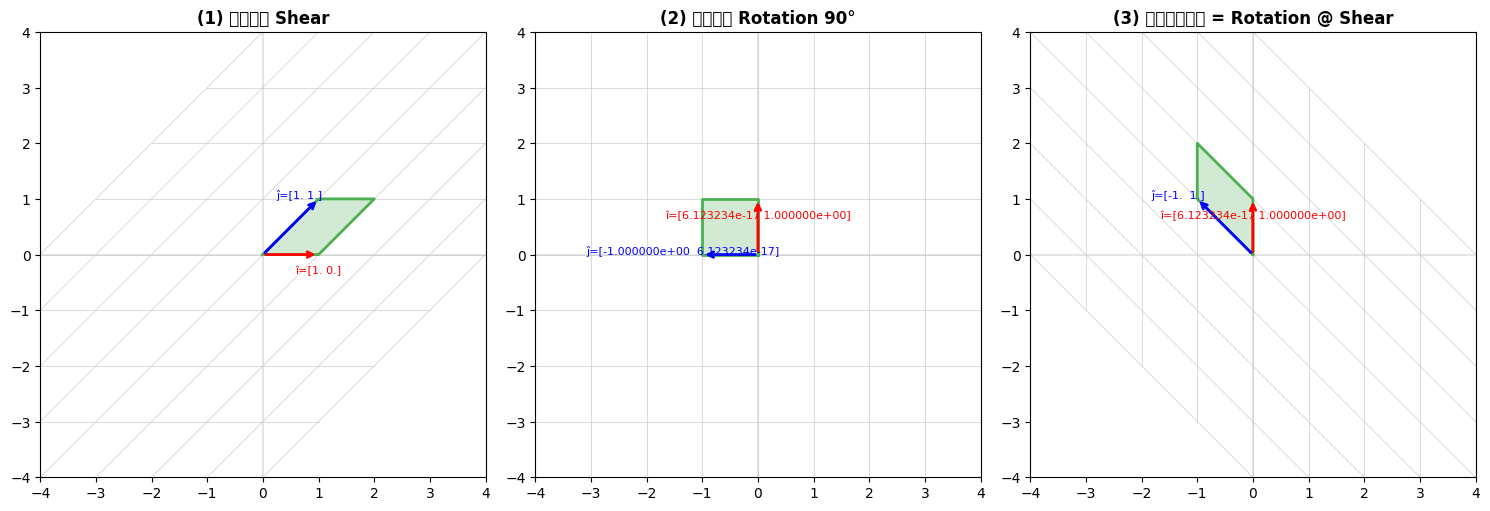

In [2]:
# ── Part 1: Composition = Matrix Multiplication ──────────────────────────

# Define two transformations
theta = np.pi / 2  # 90 degrees
Rotation = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])
Shear = np.array([[1, 1],
                   [0, 1]])

# Composition: first Shear, then Rotation
Composed = Rotation @ Shear

print("Rotation (90°):\n", np.round(Rotation, 2))
print("\nShear:\n", Shear)
print("\nRotation @ Shear (= first shear, then rotate):\n", np.round(Composed, 2))

# ── Visualize side by side ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

draw_transformed(axes[0], Shear, title="(1) 只做剪切 Shear")
draw_transformed(axes[1], Rotation, title="(2) 只做旋轉 Rotation 90°")
draw_transformed(axes[2], Composed, title="(3) 先剪切再旋轉 = Rotation @ Shear")

plt.tight_layout()
plt.show()

## Part 2：順序很重要！（不滿足交換律）

$$AB \neq BA$$

「先剪切再旋轉」和「先旋轉再剪切」的結果**完全不同**。

直覺上很好理解：你先把東西歪掉再轉，跟先轉了再歪，當然不一樣。

AB = Rotation @ Shear:
 [[ 0. -1.]
 [ 1.  1.]]

BA = Shear @ Rotation:
 [[ 1. -1.]
 [ 1.  0.]]

AB == BA? False


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/1318116003.py:17: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/1318116003.py:17: UserWarning: Glyph 20808 (\N{CJK UNIFIED IDEOGRAPH-5148}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/1318116003.py:17: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/1318116003.py:17: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/1318116003.py:17: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h8400

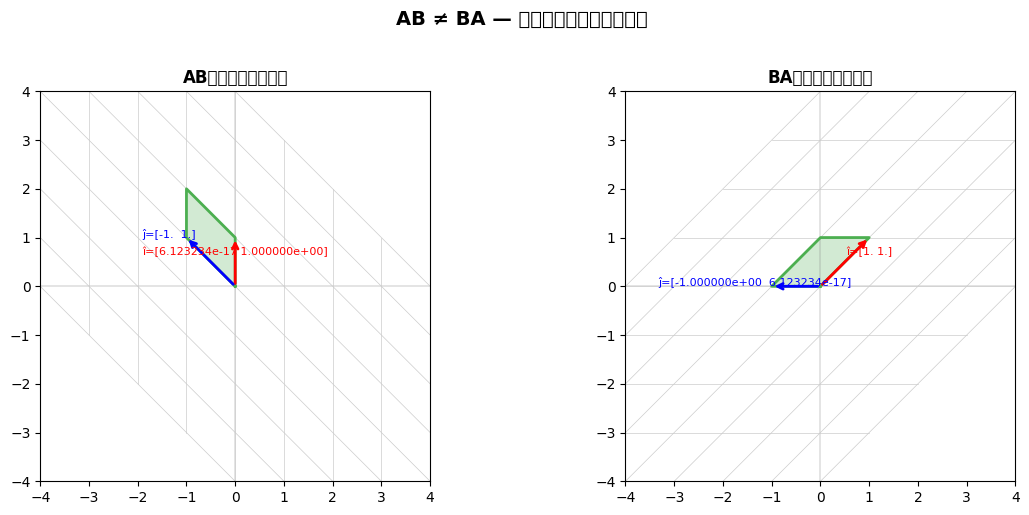

In [3]:
# ── Part 2: Order matters! AB ≠ BA ────────────────────────────────────

AB = Rotation @ Shear   # First shear, then rotate
BA = Shear @ Rotation   # First rotate, then shear

print("AB = Rotation @ Shear:\n", np.round(AB, 2))
print("\nBA = Shear @ Rotation:\n", np.round(BA, 2))
print("\nAB == BA?", np.array_equal(np.round(AB, 10), np.round(BA, 10)))

# ── Visualize side by side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

draw_transformed(axes[0], AB, title="AB：先剪切，再旋轉")
draw_transformed(axes[1], BA, title="BA：先旋轉，再剪切")

fig.suptitle("AB ≠ BA — 矩陣乘法不滿足交換律！", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part 3：但滿足結合律！

$$A(BC) = (AB)C$$

順序不能換，但**分組方式**不影響結果。

**直覺**：三個變換 A, B, C 的執行順序固定是 C → B → A。  
你只是選擇「先預計算哪一段」：
- $A(BC)$：先把 B 和 C 合成一步，再跟 A 合
- $(AB)C$：先把 A 和 B 合成一步，再跟 C 合

不管怎麼分組，最終效果一模一樣。

In [4]:
# ── Part 3: Associativity A(BC) = (AB)C ──────────────────────────────

A = np.array([[1, 2],
              [0, 1]])   # Shear-like
B = np.array([[0, -1],
              [1,  0]])  # Rotation 90°
C = np.array([[2, 0],
              [0, 2]])   # Scaling x2

left  = A @ (B @ C)      # A(BC)
right = (A @ B) @ C      # (AB)C

print("A:\n", A)
print("B:\n", B)
print("C:\n", C)
print("\nA @ (B @ C):\n", left)
print("(A @ B) @ C:\n", right)
print("\nA(BC) == (AB)C?", np.allclose(left, right))

A:
 [[1 2]
 [0 1]]
B:
 [[ 0 -1]
 [ 1  0]]
C:
 [[2 0]
 [0 2]]

A @ (B @ C):
 [[ 4 -2]
 [ 2  0]]
(A @ B) @ C:
 [[ 4 -2]
 [ 2  0]]

A(BC) == (AB)C? True


## Part 4：矩陣乘法的幾何理解 — 追蹤基底

$M_1 M_2$ 的計算過程可以這樣理解：

1. $M_2$ 把 $\hat{i} \to \text{col}_1(M_2)$，$\hat{j} \to \text{col}_2(M_2)$
2. 然後 $M_1$ 把這些結果**再變換一次**

所以：
$$M_1 M_2 = \Big[\; M_1 \cdot \text{col}_1(M_2) \;\Big|\; M_1 \cdot \text{col}_2(M_2) \;\Big]$$

> 複合矩陣的**第一 column** = $M_1$ 作用在 $M_2$ 的第一 column 上  
> 複合矩陣的**第二 column** = $M_1$ 作用在 $M_2$ 的第二 column 上

M2 的 columns（î, ĵ 經過 M2 之後）：
  col1 = [1 1]    col2 = [-1  2]

再用 M1 作用上去：
  M1 @ col1 = [ 1 -1]
  M1 @ col2 = [2 1]

手動拼起來：
 [[ 1  2]
 [-1  1]]

NumPy 直接算 M1 @ M2：
 [[ 1  2]
 [-1  1]]

結果一致？ True


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2515648915.py:31: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2515648915.py:31: UserWarning: Glyph 40670 (\N{CJK UNIFIED IDEOGRAPH-9EDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2515648915.py:31: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2515648915.py:31: UserWarning: Glyph 22871 (\N{CJK UNIFIED IDEOGRAPH-5957}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_43797/2515648915.py:31: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds

/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 40670 (\N{CJK UNIFIED IDEOGRAPH-9EDE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22871 (\N{CJK UNIFIED IDEOGRAPH-5957}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py

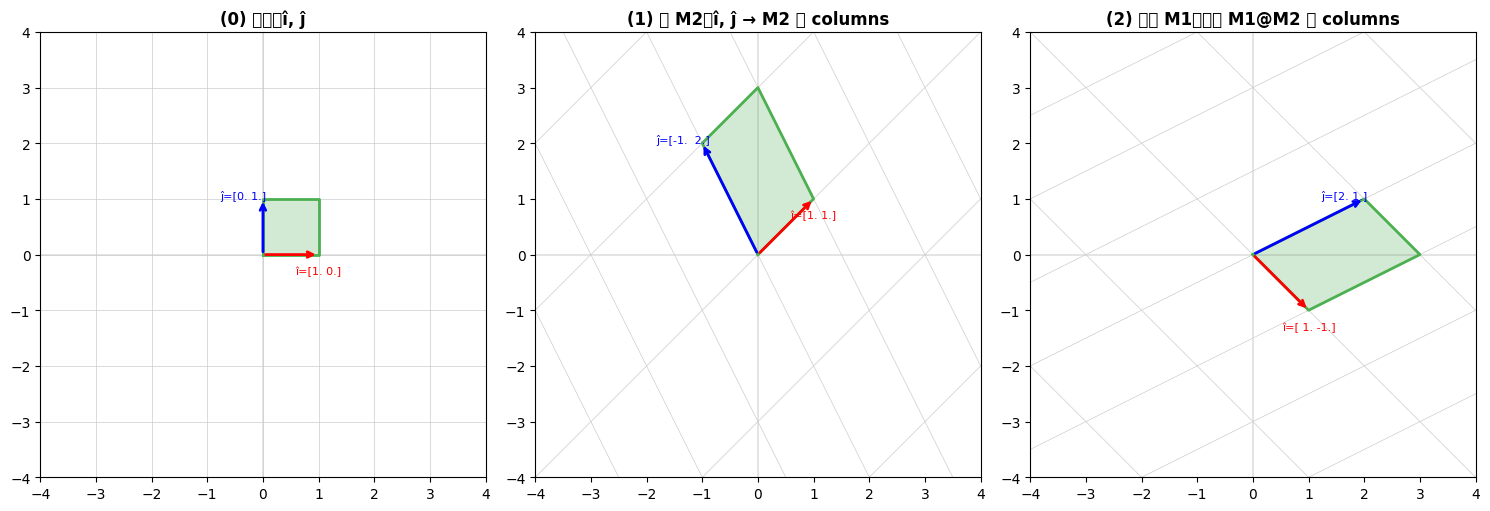

In [5]:
# ── Part 4: 追蹤基底 — 視覺化複合矩陣的每一 column ──────────────────

M2 = np.array([[1, -1],
               [1,  2]])   # 先做：把 î, ĵ 送到 (1,1) 和 (-1,2)
M1 = np.array([[0, 1],
               [-1, 0]])   # 後做：旋轉 -90°

# 數學上：M1 @ M2 的第 k 個 column = M1 作用在 M2 的第 k 個 column
M2_col1, M2_col2 = M2[:, 0], M2[:, 1]
new_col1 = M1 @ M2_col1
new_col2 = M1 @ M2_col2

Composed = M1 @ M2

print("M2 的 columns（î, ĵ 經過 M2 之後）：")
print("  col1 =", M2_col1, "   col2 =", M2_col2)
print("\n再用 M1 作用上去：")
print("  M1 @ col1 =", new_col1)
print("  M1 @ col2 =", new_col2)
print("\n手動拼起來：\n", np.column_stack([new_col1, new_col2]))
print("\nNumPy 直接算 M1 @ M2：\n", Composed)
print("\n結果一致？", np.array_equal(np.column_stack([new_col1, new_col2]), Composed))

# ── 視覺化：左→中→右 的 column 變換 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

draw_transformed(axes[0], None, title="(0) 起點：î, ĵ")
draw_transformed(axes[1], M2,   title="(1) 套 M2：î, ĵ → M2 的 columns")
draw_transformed(axes[2], Composed, title="(2) 再套 M1：得到 M1@M2 的 columns")

plt.tight_layout()
plt.show()


## 總結

| 性質 | 是否成立 | 直覺 |
|---|---|---|
| 交換律 $AB = BA$ | ❌ | 「先剪切再旋轉」≠「先旋轉再剪切」 |
| 結合律 $A(BC) = (AB)C$ | ✔️ | 順序固定（C→B→A），只是預計算分組不同 |
| 順序意義 | $M_1 M_2$ = 先做 $M_2$，再做 $M_1$ | 跟函數複合 $f(g(x))$ 一樣，右邊先做 |

### 一句話記住

> **矩陣乘法 = 線性變換的複合**。
>
> $M_1 M_2$ 的第 $k$ 個 column = $M_1$ 作用在 $M_2$ 的第 $k$ 個 column 上。

### 為什麼這在深度學習裡很重要？

神經網路的一層是 $\mathbf{y} = W \mathbf{x} + \mathbf{b}$。  
**多層網路 = 多個線性變換（加上非線性）的複合**。  
如果中間沒有非線性激活，那 $W_3 W_2 W_1 \mathbf{x}$ 其實只等於一個矩陣 $W' \mathbf{x}$ — 整個深網路會塌成一層。  
這正是為什麼我們需要 ReLU、sigmoid 這些東西的根本原因。
